In [1]:
%pip install -q joblib scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

ruta = Path("..")
datos = pd.read_csv(ruta / "data" / "beisbol.csv")
datos = datos.drop(columns=[c for c in datos.columns if c.startswith("Unnamed")])
datos.head()

,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


In [3]:
print("Dimensiones:", datos.shape)
print("\nTipos de datos:")
print(datos.dtypes)
print("\nValores nulos:")
print(datos.isna().sum())
print("\nEstadisticas descriptivas:")
datos.describe()

Dimensiones: (30, 3)

Tipos de datos:
equipos      str
bateos     int64
runs       int64
dtype: object

Valores nulos:
equipos    0
bateos     0
runs       0
dtype: int64

Estadisticas descriptivas:


,bateos,runs
count,30.000000,30.000000
mean,5523.500000,693.600000
std,79.873067,82.479088
min,5417.000000,556.000000
25%,5448.250000,629.000000
50%,5515.500000,705.500000
75%,5575.000000,734.000000
max,5710.000000,875.000000


In [4]:
correlacion = datos["bateos"].corr(datos["runs"])
print(f"Correlación bateos-runs: {correlacion:.3f}")

Correlación bateos-runs: 0.611


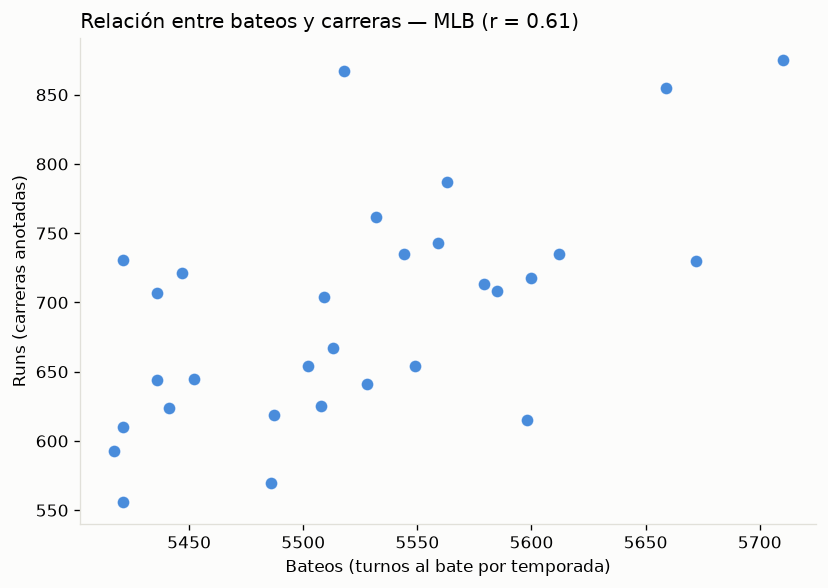

In [5]:
BLUE = "#2a78d6"
ORANGE = "#eb6834"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
ax.scatter(datos["bateos"], datos["runs"], s=60, color=BLUE, alpha=0.85,
           edgecolor="white", linewidth=0.8, zorder=3)
ax.set_xlabel("Bateos (turnos al bate por temporada)")
ax.set_ylabel("Runs (carreras anotadas)")
ax.set_title(f"Relación entre bateos y carreras — MLB (r = {correlacion:.2f})", loc="left")
fig.tight_layout()
fig.savefig(ruta / "figures" / "sa_beisbol_dispersion.png", facecolor=SURFACE)
plt.show()

In [6]:
x = datos[["bateos"]]
y = datos["runs"]

x_entrena, x_prueba, y_entrena, y_prueba = train_test_split(
    x, y, test_size=0.2, random_state=42
)

validacion = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"Entrenamiento: {x_entrena.shape[0]} equipos | Prueba: {x_prueba.shape[0]} equipos")

Entrenamiento: 24 equipos | Prueba: 6 equipos


In [7]:
modelo_base = LinearRegression()
modelo_base.fit(x_entrena, y_entrena)
pred_base = modelo_base.predict(x_prueba)

print(f"Ecuación: runs = {modelo_base.coef_[0]:.4f} * bateos + {modelo_base.intercept_:.2f}")

scores_cv_base = cross_val_score(modelo_base, x, y, cv=validacion, scoring="r2")
print("R2 por fold (validación cruzada, 5-fold):", np.round(scores_cv_base, 3))
print("R2 promedio (CV):", round(scores_cv_base.mean(), 3))

Ecuación: runs = 0.6669 * bateos + -2981.52
R2 por fold (validación cruzada, 5-fold): [-0.517  0.518  0.676 -0.267 -0.273]
R2 promedio (CV): 0.027


In [8]:
pipeline_ridge = Pipeline([
    ("escala", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("ridge", Ridge()),
])

rejilla = {
    "poly__degree": [1, 2, 3],
    "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
}

busqueda = GridSearchCV(
    pipeline_ridge, rejilla, cv=validacion, scoring="r2", n_jobs=-1
)
busqueda.fit(x_entrena, y_entrena)

print("Mejores hiperparámetros:", busqueda.best_params_)
print("Mejor R2 (CV, train):", round(busqueda.best_score_, 3))

modelo_optimizado = busqueda.best_estimator_
pred_optimizado = modelo_optimizado.predict(x_prueba)

Mejores hiperparámetros: {'poly__degree': 1, 'ridge__alpha': 10}
Mejor R2 (CV, train): 0.256


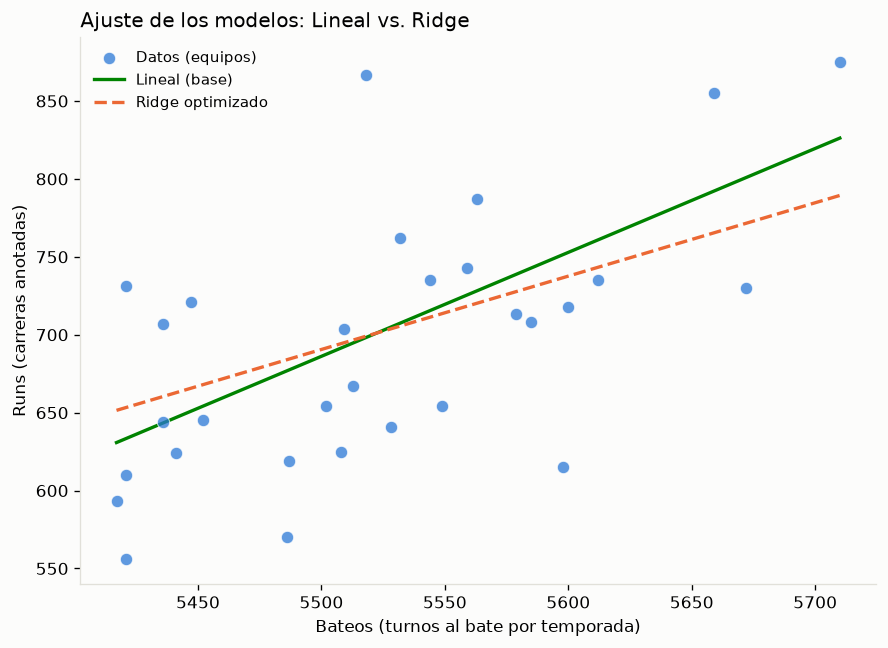

In [9]:
eje_x = pd.DataFrame({"bateos": np.linspace(datos["bateos"].min(), datos["bateos"].max(), 200)})

fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=120)
ax.scatter(datos["bateos"], datos["runs"], s=55, color=BLUE, alpha=0.75,
           edgecolor="white", linewidth=0.6, zorder=3, label="Datos (equipos)")
ax.plot(eje_x["bateos"], modelo_base.predict(eje_x), color="#008300", linewidth=2,
        label="Lineal (base)")
ax.plot(eje_x["bateos"], modelo_optimizado.predict(eje_x), color=ORANGE, linewidth=2,
        linestyle="--", label="Ridge optimizado")
ax.set_xlabel("Bateos (turnos al bate por temporada)")
ax.set_ylabel("Runs (carreras anotadas)")
ax.set_title("Ajuste de los modelos: Lineal vs. Ridge", loc="left")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(ruta / "figures" / "sa_regresion_lineal_ridge.png", facecolor=SURFACE)
plt.show()

In [10]:
resultados = pd.DataFrame({
    "modelo": ["Lineal (base)", "Ridge optimizado"],
    "MAE": [
        mean_absolute_error(y_prueba, pred_base),
        mean_absolute_error(y_prueba, pred_optimizado),
    ],
    "RMSE": [
        mean_squared_error(y_prueba, pred_base) ** 0.5,
        mean_squared_error(y_prueba, pred_optimizado) ** 0.5,
    ],
    "R2": [
        r2_score(y_prueba, pred_base),
        r2_score(y_prueba, pred_optimizado),
    ],
})
resultados

,modelo,MAE,RMSE,R2
0,Lineal (base),51.611641,72.249399,-0.517484
1,Ridge optimizado,51.047759,69.744774,-0.414096


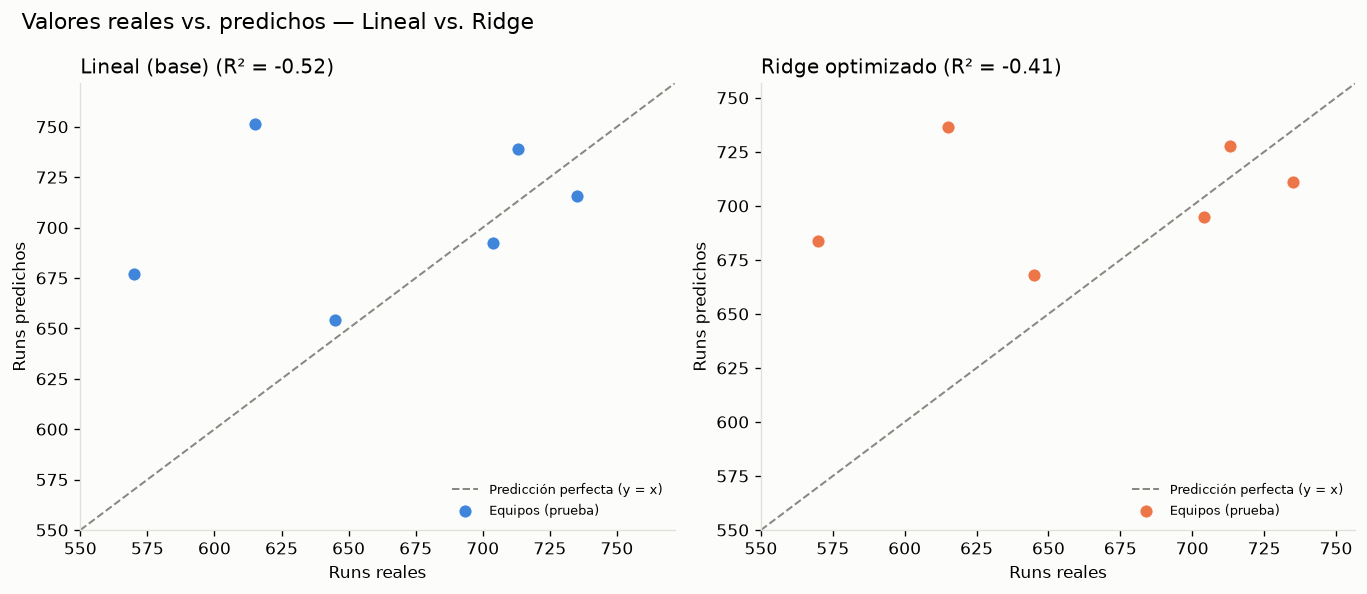

In [11]:
fig, ejes = plt.subplots(1, 2, figsize=(11.5, 5), dpi=120)

for ax, prediccion, nombre, color in zip(
    ejes, [pred_base, pred_optimizado], ["Lineal (base)", "Ridge optimizado"], [BLUE, ORANGE]
):
    lims = [min(y_prueba.min(), prediccion.min()) - 20, max(y_prueba.max(), prediccion.max()) + 20]
    ax.plot(lims, lims, color=MUTED, linestyle="--", linewidth=1.2, label="Predicción perfecta (y = x)")
    ax.scatter(y_prueba, prediccion, s=65, color=color, alpha=0.9,
               edgecolor="white", linewidth=0.8, zorder=3, label="Equipos (prueba)")
    r2 = r2_score(y_prueba, prediccion)
    ax.set_xlabel("Runs reales")
    ax.set_ylabel("Runs predichos")
    ax.set_title(f"{nombre} (R² = {r2:.2f})", loc="left")
    ax.legend(frameon=False, fontsize=8)
    ax.set_xlim(lims); ax.set_ylim(lims)

fig.suptitle("Valores reales vs. predichos — Lineal vs. Ridge", x=0.02, ha="left", fontsize=13)
fig.tight_layout()
fig.savefig(ruta / "figures" / "sa_beisbol_real_vs_predicho.png", facecolor=SURFACE)
plt.show()

In [12]:
joblib.dump(modelo_base, ruta / "models" / "sa_regresion_lineal_beisbol.joblib")
joblib.dump(modelo_optimizado, ruta / "models" / "sa_ridge_beisbol.joblib")
print("Modelos guardados en la carpeta models/")

Modelos guardados en la carpeta models/
